# Sistem Pendukung Keputusan Klinis untuk Klasifikasi Pasien DBD Berdasarkan Kode ICD A90 dan A91 Menggunakan Metode CRISP-DM

---

**Judul Penelitian**
Sistem Pendukung Keputusan Klinis untuk Klasifikasi Pasien DBD Berdasarkan Kode ICD A90 dan A91 Menggunakan Metode CRISP-DM

**Algoritma**: Decision Tree Classifier
**Framework Penelitian**: CRISP-DM (Cross Industry Standard Process for Data Mining)
**Sumber Data**: Data Rekam Medis Pasien DBD Rumah Sakit Aulia (3.000 rekam medis)

---

## Tujuan Notebook

Notebook ini disusun untuk mendokumentasikan secara menyeluruh seluruh tahapan penelitian, mulai dari pemahaman data (*Data Understanding*), persiapan data (*Data Preparation*), pembangunan model (*Modeling*), evaluasi performa model (*Evaluation*), hingga finalisasi model yang siap diimplementasikan pada sistem pendukung keputusan klinis. Setiap tahapan disertai penjelasan naratif agar proses analisis dapat dipahami secara ilmiah dan dapat dipertanggungjawabkan secara metodologis sesuai dengan kerangka kerja CRISP-DM yang dijelaskan pada BAB III.

Model yang dibangun bertujuan mengklasifikasikan pasien DBD ke dalam dua kategori diagnosis ICD-10, yaitu **A90 (Dengue Fever)** dan **A91 (Dengue Hemorrhagic Fever)**, berdasarkan enam variabel yaitu Usia, Jenis Kelamin, Trombosit, Hematokrit, Hemoglobin, dan Leukosit.

## 1. Import Library

Bagian ini memuat seluruh pustaka (*library*) Python yang digunakan dalam proses analisis data, pemodelan, dan evaluasi. Hanya pustaka yang benar-benar digunakan dalam alur penelitian yang diimpor.

In [1]:
# Manipulasi dan analisis data
import pandas as pd
import numpy as np
import re

# Visualisasi data
import matplotlib.pyplot as plt
import seaborn as sns

# Statistik
from scipy import stats

# Preprocessing dan pemodelan
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                              precision_score, recall_score, f1_score, ConfusionMatrixDisplay)

# Penanganan data tidak seimbang
from imblearn.over_sampling import SMOTE

# Penyimpanan model
import joblib

# Pengaturan tampilan
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.facecolor'] = 'white'

RANDOM_STATE = 42
print("Seluruh library berhasil diimpor.")

Seluruh library berhasil diimpor.


## 2. Data Understanding

Tahap *Data Understanding* bertujuan untuk memahami struktur, karakteristik, dan kualitas data rekam medis pasien DBD Rumah Sakit Aulia sebelum data digunakan pada tahap selanjutnya.

### 2.1 Load Dataset

In [2]:
df_raw = pd.read_excel('Data_Lab_Penyakit_DBD_RS_Aulia.xlsx')
print(f"Jumlah baris  : {df_raw.shape[0]}")
print(f"Jumlah kolom  : {df_raw.shape[1]}")
df_raw.shape

Jumlah baris  : 3000
Jumlah kolom  : 15


(3000, 15)

In [3]:
# Lima data pertama
df_raw.head()

,No,No. Rekam Medis,Unit / Poli,Pelayanan,Usia (tahun),Jenis Kelamin\n(L/P),Suhu Tubuh (°C),Tanggal Masuk,Trombosit\n(ribu/μL),Hematokrit (%),Hemoglobin (g/dL),Leukosit\n(ribu/μL),kode ICD,Diagnosa,Keluhan
0,1,254264,INSTALASI GAWAT DARURAT,Rawat Jalan,25 Th 8 Bl 9 Hr ...,P,36.0,2026-05-15 00:00:00.000,"137000 (150,000-450,000)",29 (35-47),10.6 (11.5-16.0),"5400 (4,000-11,000)",A91,Dengue haemorrhagic fever,demam pusing
1,2,253925,INSTALASI GAWAT DARURAT,Rawat Inap,5 Th 5 Bl 17 Hr ...,L,0.0,2026-05-08 00:00:00.000,"81000 (150,000-450,000)",39 (40-52),12.8 (13.5-18.0),"1600 (4,000-11,000)",A91,Dengue haemorrhagic fever,NaN
2,3,189784,INSTALASI GAWAT DARURAT,Rawat Inap,34 Th 7 Bl 12 Hr ...,P,0.0,2026-05-07 00:00:00.000,"87000 (150,000-450,000)",38 (35-47),12.9 (11.5-16.0),"3400 (4,000-11,000)",A91,Dengue haemorrhagic fever,NaN
3,4,253342,POLIKLINIK PENYAKIT DALAM,Rawat Jalan,25 Th 6 Bl 4 Hr ...,P,36.0,2026-05-05 00:00:00.000,NaN,NaN,NaN,NaN,A90,Dengue fever [classical dengue],KONTROL PASCA RANAP
4,5,253814,INSTALASI GAWAT DARURAT,Rawat Jalan,46 Th 1 Bl 21 Hr ...,L,0.0,2026-05-05 00:00:00.000,"53000 (150,000-450,000)",44 (40-52),15.5 (13.5-18.0),"12600 (4,000-11,000)",A90,Dengue fever [classical dengue],NaN


In [4]:
# Lima data terakhir
df_raw.tail()

,No,No. Rekam Medis,Unit / Poli,Pelayanan,Usia (tahun),Jenis Kelamin\n(L/P),Suhu Tubuh (°C),Tanggal Masuk,Trombosit\n(ribu/μL),Hematokrit (%),Hemoglobin (g/dL),Leukosit\n(ribu/μL),kode ICD,Diagnosa,Keluhan
2995,2996,198014,INSTALASI GAWAT DARURAT,Rawat Inap,20 Th 5 Bl 15 Hr ...,P,0.0,2023-08-02 00:00:00.000,"102000 (150,000-450,000)",33 (35-47),11.4 (11.5-16.0),"1400 (4,000-11,000)",A91,Dengue haemorrhagic fever,NaN
2996,2997,198023,INSTALASI GAWAT DARURAT,Rawat Inap,6 Th 7 Bl 24 Hr ...,L,0.0,2023-08-02 00:00:00.000,"147000 (150,000-450,000)",35 (40-52),11.9 (13.5-18.0),"5600 (4,000-11,000)",A90,Dengue fever [classical dengue],NaN
2997,2998,121314,INSTALASI GAWAT DARURAT,Rawat Jalan,10 Th 12 Hr ...,P,368.0,2023-08-01 00:00:00.000,"147000 (150,000-450,000)",33 (35-47),11.4 (11.5-16.0),"9600 (4,000-11,000)",A90,Dengue fever [classical dengue],DEMAM 5 HARI
2998,2999,158232,INSTALASI GAWAT DARURAT,Rawat Inap,9 Th 2 Bl 29 Hr ...,P,0.0,2023-08-01 00:00:00.000,"128000 (150,000-450,000)",32 (35-47),11.6 (11.5-16.0),"1800 (4,000-11,000)",A90,Dengue fever [classical dengue],NaN
2999,3000,197943,INSTALASI GAWAT DARURAT,Rawat Inap,3 Th 3 Bl 11 Hr ...,P,0.0,2023-08-01 00:00:00.000,"108000 (150,000-450,000), 115000 (150,000-450,...","34 (35-47), 35 (35-47)","11.4 (11.5-16.0), 11.5 (11.5-16.0)","2800 (4,000-11,000), 2900 (4,000-11,000)",A90,Dengue fever [classical dengue],NaN


In [5]:
# Nama seluruh kolom pada dataset
df_raw.columns.tolist()

['No',
 'No. Rekam Medis',
 'Unit / Poli',
 'Pelayanan',
 'Usia (tahun)',
 'Jenis Kelamin\n(L/P)',
 'Suhu Tubuh (°C)',
 'Tanggal Masuk',
 'Trombosit\n(ribu/μL)',
 'Hematokrit (%)',
 'Hemoglobin (g/dL)',
 'Leukosit\n(ribu/μL)',
 'kode ICD',
 'Diagnosa',
 'Keluhan']

In [6]:
# Tipe data masing-masing kolom
df_raw.dtypes

No                        int64
No. Rekam Medis           int64
Unit / Poli                 str
Pelayanan                   str
Usia (tahun)                str
Jenis Kelamin\n(L/P)        str
Suhu Tubuh (°C)         float64
Tanggal Masuk               str
Trombosit\n(ribu/μL)        str
Hematokrit (%)              str
Hemoglobin (g/dL)           str
Leukosit\n(ribu/μL)         str
kode ICD                    str
Diagnosa                    str
Keluhan                     str
dtype: object

In [7]:
# Informasi umum dataset
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   No                   3000 non-null   int64  
 1   No. Rekam Medis      3000 non-null   int64  
 2   Unit / Poli          3000 non-null   str    
 3   Pelayanan            3000 non-null   str    
 4   Usia (tahun)         3000 non-null   str    
 5   Jenis Kelamin
(L/P)  3000 non-null   str    
 6   Suhu Tubuh (°C)      3000 non-null   float64
 7   Tanggal Masuk        3000 non-null   str    
 8   Trombosit
(ribu/μL)  1755 non-null   str    
 9   Hematokrit (%)       1755 non-null   str    
 10  Hemoglobin (g/dL)    1755 non-null   str    
 11  Leukosit
(ribu/μL)   1755 non-null   str    
 12  kode ICD             3000 non-null   str    
 13  Diagnosa             3000 non-null   str    
 14  Keluhan              1328 non-null   str    
dtypes: float64(1), int64(2), str(12)
memory usage: 35

In [8]:
# Statistik deskriptif dataset
df_raw.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
No,3000.0,NaN,NaN,NaN,1500.5,866.169729,1.0,750.75,1500.5,2250.25,3000.0
No. Rekam Medis,3000.0,NaN,NaN,NaN,193387.468,49451.413766,6826.0,168226.5,211157.5,229460.0,254264.0
Unit / Poli,3000,10,INSTALASI GAWAT DARURAT,2394,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pelayanan,3000,2,Rawat Inap,1608,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Usia (tahun),3000,1879,8 Th 10 Bl 10 Hr ...,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Jenis Kelamin\n(L/P),3000,2,L,1507,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Suhu Tubuh (°C),3000.0,NaN,NaN,NaN,21.51936,48.841917,0.0,0.0,0.0,36.0,387.0
Tanggal Masuk,3000,843,2025-04-10 00:00:00.000,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Trombosit\n(ribu/μL),1755,404,"135000 (150,000-450,000)",32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Hematokrit (%),1755,193,40 (35-47),75,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Catatan Data Understanding:**

Dataset yang diterima dari Rumah Sakit Aulia berisi 15 kolom, namun sebagaimana dijelaskan pada BAB III, hanya enam variabel prediktor (Usia, Jenis Kelamin, Trombosit, Hematokrit, Hemoglobin, Leukosit) dan satu variabel target (kode ICD) yang digunakan dalam penelitian ini. Beberapa kolom numerik pada data mentah (Usia, Trombosit, Hematokrit, Hemoglobin, Leukosit) masih berformat teks (*string*) karena hasil ekspor sistem laboratorium menyertakan satuan, rentang nilai rujukan, dan/atau komponen tambahan dalam satu sel (contoh: `"137000 (150,000-450,000)"` untuk Trombosit dan `"25 Th 8 Bl 9 Hr"` untuk Usia). Kondisi ini akan ditangani pada tahap *Data Preparation*.

### 2.2 Distribusi Target

In [9]:
target_counts = df_raw['kode ICD'].value_counts()
target_percent = df_raw['kode ICD'].value_counts(normalize=True) * 100

print("Jumlah data per kelas ICD:")
print(target_counts)
print("\nPersentase data per kelas ICD:")
print(target_percent.round(2))

Jumlah data per kelas ICD:
kode ICD
A90    2431
A91     569
Name: count, dtype: int64

Persentase data per kelas ICD:
kode ICD
A90    81.03
A91    18.97
Name: proportion, dtype: float64


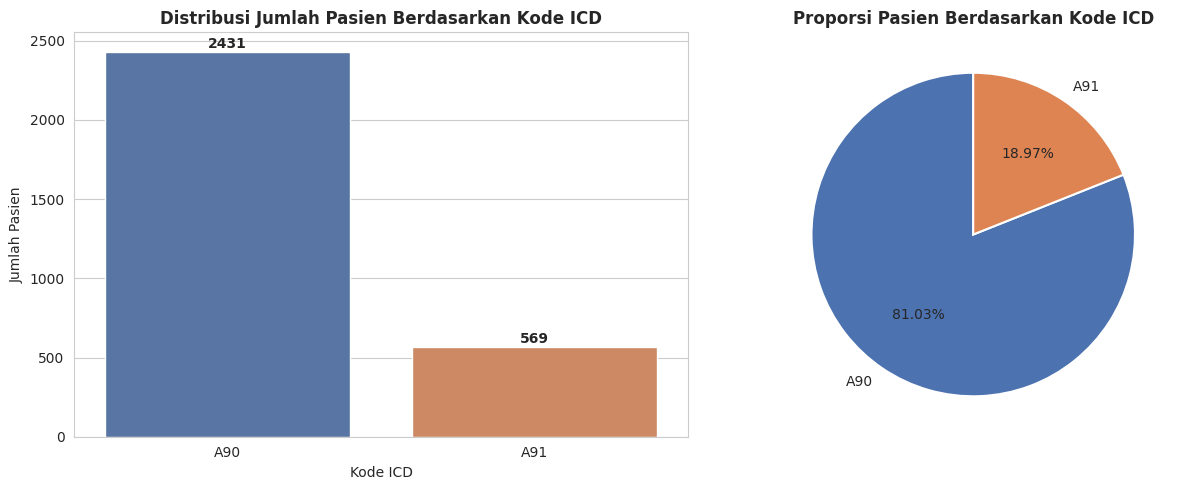

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
sns.barplot(x=target_counts.index, y=target_counts.values, hue=target_counts.index,
            palette=['#4C72B0', '#DD8452'], ax=axes[0], legend=False)
axes[0].set_title('Distribusi Jumlah Pasien Berdasarkan Kode ICD', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Kode ICD')
axes[0].set_ylabel('Jumlah Pasien')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(target_counts.values, labels=target_counts.index, autopct='%1.2f%%',
            colors=['#4C72B0', '#DD8452'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Proporsi Pasien Berdasarkan Kode ICD', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('distribusi_target.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretasi Distribusi Target:**

Visualisasi di atas menunjukkan bahwa jumlah pasien dengan kode diagnosis A90 (*Dengue Fever*) jauh lebih banyak dibandingkan pasien dengan kode diagnosis A91 (*Dengue Hemorrhagic Fever*). Kondisi ini mengindikasikan adanya ketidakseimbangan kelas (*class imbalance*) pada variabel target, yang apabila tidak ditangani dapat menyebabkan model klasifikasi cenderung bias terhadap kelas mayoritas (A90) dan kurang mampu mengenali kelas minoritas (A91). Mengingat A91 merupakan kategori dengan risiko klinis yang lebih tinggi, ketidakseimbangan ini menjadi perhatian khusus dan akan ditangani menggunakan teknik SMOTE pada tahap *Data Preparation*.

## 3. Data Preparation

Tahap *Data Preparation* bertujuan mengubah data mentah menjadi dataset yang bersih dan siap digunakan sebagai input pemodelan. Tahapan ini mencakup seleksi variabel, konversi format, penanganan *missing value*, pemeriksaan data duplikat, pemeriksaan *outlier*, standardisasi variabel kategorikal, *encoding*, pembagian data latih dan data uji, serta penanganan ketidakseimbangan kelas.

### 3.1 Seleksi Variabel

Sebagaimana dijelaskan pada BAB III, seleksi variabel dilakukan berdasarkan kajian literatur dan relevansi klinis. Variabel yang dipertahankan sebagai fitur input pemodelan adalah Usia, Jenis Kelamin, Trombosit, Hematokrit, Hemoglobin, dan Leukosit, karena variabel-variabel tersebut memiliki keterkaitan langsung dengan kondisi hematologis pasien DBD dan menjadi acuan utama dalam penetapan derajat keparahan penyakit. Variabel administratif lain pada data mentah (nomor rekam medis, unit/poli, tanggal masuk, keluhan, dan sebagainya) tidak digunakan karena tidak relevan secara klinis terhadap proses klasifikasi.

In [11]:
kolom_dipilih = {
    'Usia (tahun)': 'Usia',
    'Jenis Kelamin\n(L/P)': 'Jenis_Kelamin',
    'Trombosit\n(ribu/μL)': 'Trombosit',
    'Hematokrit (%)': 'Hematokrit',
    'Hemoglobin (g/dL)': 'Hemoglobin',
    'Leukosit\n(ribu/μL)': 'Leukosit',
    'kode ICD': 'ICD'
}

df = df_raw[list(kolom_dipilih.keys())].rename(columns=kolom_dipilih).copy()
print(f"Dataset hasil seleksi variabel: {df.shape[0]} baris, {df.shape[1]} kolom")
df.head()

Dataset hasil seleksi variabel: 3000 baris, 7 kolom


,Usia,Jenis_Kelamin,Trombosit,Hematokrit,Hemoglobin,Leukosit,ICD
0,25 Th 8 Bl 9 Hr ...,P,"137000 (150,000-450,000)",29 (35-47),10.6 (11.5-16.0),"5400 (4,000-11,000)",A91
1,5 Th 5 Bl 17 Hr ...,L,"81000 (150,000-450,000)",39 (40-52),12.8 (13.5-18.0),"1600 (4,000-11,000)",A91
2,34 Th 7 Bl 12 Hr ...,P,"87000 (150,000-450,000)",38 (35-47),12.9 (11.5-16.0),"3400 (4,000-11,000)",A91
3,25 Th 6 Bl 4 Hr ...,P,NaN,NaN,NaN,NaN,A90
4,46 Th 1 Bl 21 Hr ...,L,"53000 (150,000-450,000)",44 (40-52),15.5 (13.5-18.0),"12600 (4,000-11,000)",A90


### 3.2 Konversi Format Data

Sebagaimana terlihat pada tahap *Data Understanding*, variabel Usia dan variabel laboratorium (Trombosit, Hematokrit, Hemoglobin, Leukosit) masih berformat teks campuran karena merupakan hasil ekspor langsung dari sistem informasi laboratorium rumah sakit. Variabel Usia dituliskan dalam format `"X Th Y Bl Z Hr"` (tahun, bulan, hari) atau dalam beberapa kasus `"X tahun, Y bulan, Z hari"`, sedangkan variabel laboratorium dituliskan dengan format `"nilai (rentang rujukan)"`, contoh `"137000 (150,000-450,000)"`. Sebelum dapat digunakan dalam proses pemodelan, nilai numerik pada kedua jenis variabel tersebut perlu diekstraksi terlebih dahulu menggunakan pencocokan pola teks (*regular expression*).

In [12]:
def parse_usia(teks):
    '''Mengekstraksi usia (dalam tahun) dari format teks campuran hasil rekam medis.'''
    if pd.isna(teks):
        return np.nan
    teks = str(teks).strip()
    if teks == '':
        return np.nan
    # Format dengan satuan tahun ("Th" / "tahun")
    cocok = re.search(r'(\d+)\s*(Th|tahun)', teks, re.IGNORECASE)
    if cocok:
        return float(cocok.group(1))
    # Pasien bayi (< 1 tahun), hanya tertulis dalam bulan/hari
    cocok = re.search(r'(\d+)\s*(Bl|bulan)', teks, re.IGNORECASE)
    if cocok:
        return 0.0
    return np.nan

def parse_nilai_lab(teks):
    '''Mengekstraksi nilai numerik dari format "nilai (rentang rujukan)".'''
    if pd.isna(teks):
        return np.nan
    teks = str(teks).strip()
    if teks == '':
        return np.nan
    cocok = re.search(r'([\d]+\.?[\d]*)', teks)
    return float(cocok.group(1)) if cocok else np.nan

df['Usia'] = df['Usia'].apply(parse_usia)
for kolom in ['Trombosit', 'Hematokrit', 'Hemoglobin', 'Leukosit']:
    df[kolom] = df[kolom].apply(parse_nilai_lab)

df['Jenis_Kelamin'] = df['Jenis_Kelamin'].astype(str).str.strip().str.upper()
df['ICD'] = df['ICD'].astype(str).str.strip().str.upper()

print("Konversi format data selesai.")
df.head()

Konversi format data selesai.


,Usia,Jenis_Kelamin,Trombosit,Hematokrit,Hemoglobin,Leukosit,ICD
0,25.0,P,137000.0,29.0,10.6,5400.0,A91
1,5.0,L,81000.0,39.0,12.8,1600.0,A91
2,34.0,P,87000.0,38.0,12.9,3400.0,A91
3,25.0,P,NaN,NaN,NaN,NaN,A90
4,46.0,L,53000.0,44.0,15.5,12600.0,A90


In [13]:
df.dtypes

Usia             float64
Jenis_Kelamin        str
Trombosit        float64
Hematokrit       float64
Hemoglobin       float64
Leukosit         float64
ICD                  str
dtype: object

### 3.3 Missing Value

In [14]:
missing_jumlah = df.isnull().sum()
missing_persen = (df.isnull().sum() / len(df) * 100).round(2)

missing_table = pd.DataFrame({
    'Jumlah Missing Value': missing_jumlah,
    'Persentase (%)': missing_persen
})
missing_table

,Jumlah Missing Value,Persentase (%)
Usia,2,0.07
Jenis_Kelamin,0,0.00
Trombosit,1245,41.50
Hematokrit,1245,41.50
Hemoglobin,1245,41.50
Leukosit,1245,41.50
ICD,0,0.00


Hasil pemeriksaan menunjukkan bahwa nilai *missing* terkonsentrasi pada keempat variabel laboratorium (Trombosit, Hematokrit, Hemoglobin, Leukosit). Penelusuran lebih lanjut menunjukkan bahwa nilai yang hilang pada keempat variabel tersebut terjadi secara bersamaan pada baris yang sama, yang mengindikasikan bahwa pasien terkait tidak menjalani pemeriksaan laboratorium pada kunjungan tersebut (misalnya pada kunjungan kontrol pasca rawat inap atau kunjungan rawat jalan tanpa indikasi pemeriksaan darah lengkap), bukan disebabkan oleh kesalahan pencatatan sistem. Variabel Usia memiliki proporsi *missing value* yang sangat kecil. Mengingat proporsi *missing value* pada variabel laboratorium masih berada dalam batas yang dapat ditangani melalui imputasi dan tidak mengindikasikan kesalahan sistematis pada data, maka baris-baris tersebut dipertahankan dan ditangani melalui imputasi median sebagaimana dijelaskan pada BAB III, bukan dihapus, untuk menjaga jumlah data latih tetap representatif.

In [15]:
# Menandai baris yang seluruh nilai laboratoriumnya kosong (tidak menjalani
# pemeriksaan darah lengkap pada kunjungan tersebut). Penanda ini digunakan
# sebagai bahan diagnostik pada tahap pemeriksaan duplikat berikutnya.
kolom_lab = ['Trombosit', 'Hematokrit', 'Hemoglobin', 'Leukosit']
df['_tanpa_data_lab'] = df[kolom_lab].isnull().all(axis=1)

kolom_numerik = ['Usia', 'Trombosit', 'Hematokrit', 'Hemoglobin', 'Leukosit']
kolom_kategorikal = ['Jenis_Kelamin']

imputer_numerik = SimpleImputer(strategy='median')
imputer_kategorikal = SimpleImputer(strategy='most_frequent')

df[kolom_numerik] = imputer_numerik.fit_transform(df[kolom_numerik])
df[kolom_kategorikal] = imputer_kategorikal.fit_transform(df[kolom_kategorikal])

print("Imputasi missing value selesai.")
print("\nJumlah missing value setelah imputasi:")
print(df.drop(columns=['_tanpa_data_lab']).isnull().sum())

Imputasi missing value selesai.

Jumlah missing value setelah imputasi:
Usia             0
Jenis_Kelamin    0
Trombosit        0
Hematokrit       0
Hemoglobin       0
Leukosit         0
ICD              0
dtype: int64


### 3.4 Data Duplikat

In [16]:
jumlah_duplikat = df.duplicated(subset=['Usia','Jenis_Kelamin','Trombosit','Hematokrit','Hemoglobin','Leukosit','ICD']).sum()
print(f"Jumlah baris duplikat (berdasarkan kombinasi 6 fitur + target): {jumlah_duplikat}")
print(f"Persentase terhadap total data: {jumlah_duplikat / len(df) * 100:.2f}%")

Jumlah baris duplikat (berdasarkan kombinasi 6 fitur + target): 980
Persentase terhadap total data: 32.67%


In [17]:
# Diagnostik: seberapa besar duplikat di atas berasal dari baris yang
# sebelum imputasi tidak memiliki data laboratorium sama sekali (lihat
# penanda '_tanpa_data_lab' pada tahap Missing Value)
mask_duplikat = df.duplicated(subset=['Usia','Jenis_Kelamin','Trombosit','Hematokrit','Hemoglobin','Leukosit','ICD'], keep=False)
total_dalam_grup_duplikat = mask_duplikat.sum()
tanpa_lab_dalam_grup_duplikat = df.loc[mask_duplikat, '_tanpa_data_lab'].sum()

print(f"Total baris yang tergabung dalam kelompok duplikat : {total_dalam_grup_duplikat}")
print(f"Di antaranya, baris tanpa data laboratorium asli   : {tanpa_lab_dalam_grup_duplikat} "
      f"({tanpa_lab_dalam_grup_duplikat / total_dalam_grup_duplikat * 100:.2f}%)")

Total baris yang tergabung dalam kelompok duplikat : 1199
Di antaranya, baris tanpa data laboratorium asli   : 1189 (99.17%)


**Interpretasi Hasil Pemeriksaan Duplikat:**

Jumlah duplikat yang terdeteksi berdasarkan kombinasi keenam fitur dan target cukup besar. Hasil diagnostik pada sel di atas menunjukkan bahwa sebagian besar duplikat tersebut berasal dari baris yang **tidak memiliki data laboratorium asli** (nilai Trombosit, Hematokrit, Hemoglobin, dan Leukosit kosong sebelum diimputasi). Setelah imputasi median, baris-baris tersebut memperoleh nilai laboratorium yang persis sama, sehingga apabila kebetulan memiliki kombinasi Usia, Jenis Kelamin, dan kode ICD yang sama, baris-baris tersebut menjadi tidak dapat dibedakan pada ruang fitur yang digunakan model meskipun secara administratif merupakan rekam medis pasien yang berbeda.

Karena model klasifikasi dibangun hanya berdasarkan keenam variabel terpilih, baris-baris yang identik pada ruang fitur tersebut tidak memberikan informasi tambahan bagi proses pembelajaran model dan berpotensi menyebabkan bobot berlebih (*redundansi*) pada kombinasi nilai tertentu apabila tetap dipertahankan. Oleh karena itu, baris duplikat tetap dihapus mengikuti prosedur pada BAB III. Meskipun demikian, proporsi duplikat yang cukup besar ini perlu dilaporkan secara eksplisit sebagai keterbatasan penelitian, karena sebagiannya merupakan konsekuensi dari tingginya proporsi *missing value* pada variabel laboratorium, bukan duplikasi rekam medis dalam pengertian administratif. Penjelasan mengenai keterbatasan ini sebaiknya turut dicantumkan pada bagian Pembahasan/Keterbatasan Penelitian di BAB IV.

In [18]:
df = df.drop_duplicates(subset=['Usia','Jenis_Kelamin','Trombosit','Hematokrit','Hemoglobin','Leukosit','ICD']).reset_index(drop=True)
df = df.drop(columns=['_tanpa_data_lab'])

print(f"Jumlah data setelah penghapusan duplikat: {df.shape[0]} baris")

Jumlah data setelah penghapusan duplikat: 2020 baris


### 3.5 Pemeriksaan Outlier

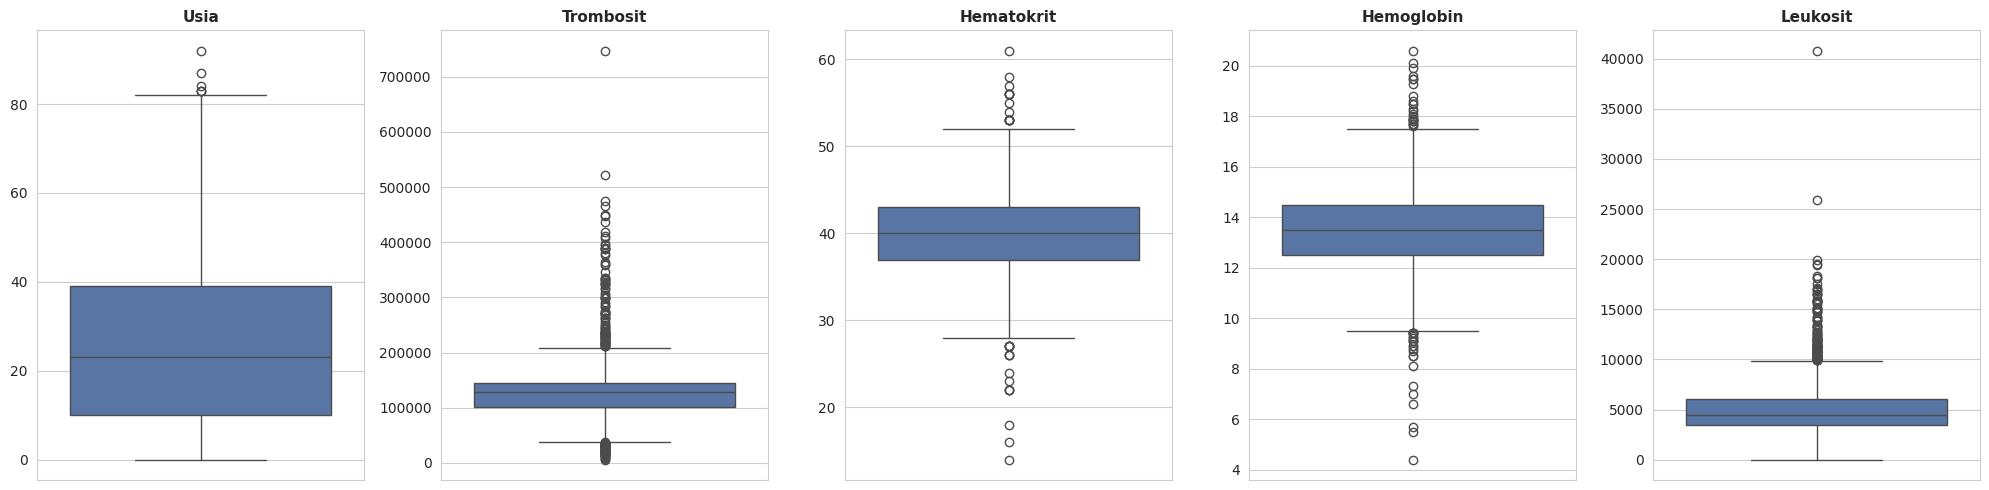

In [19]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
kolom_boxplot = ['Usia', 'Trombosit', 'Hematokrit', 'Hemoglobin', 'Leukosit']

for i, kolom in enumerate(kolom_boxplot):
    sns.boxplot(y=df[kolom], ax=axes[i], color='#4C72B0')
    axes[i].set_title(kolom, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.savefig('boxplot_outlier.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretasi Pemeriksaan Outlier:**

Visualisasi *boxplot* di atas menunjukkan adanya sejumlah nilai ekstrem pada variabel laboratorium, khususnya pada Trombosit dan Leukosit. Nilai trombosit yang sangat rendah konsisten dengan kondisi trombositopenia berat yang umum dijumpai pada pasien DBD, khususnya kategori A91, sehingga nilai tersebut merepresentasikan kondisi klinis yang valid dan tetap dipertahankan dalam dataset. Sejalan dengan penjelasan pada BAB III, nilai ekstrem hanya akan diperlakukan sebagai kesalahan pencatatan apabila secara klinis tidak mungkin terjadi (misalnya nilai nol atau negatif pada variabel yang seharusnya selalu positif). Berdasarkan pemeriksaan, tidak ditemukan nilai yang secara klinis mustahil pada kelima variabel, sehingga seluruh data outlier yang teramati dipertahankan tanpa penghapusan.

In [20]:
# Pemeriksaan nilai yang secara klinis tidak mungkin (nol atau negatif)
print("Jumlah nilai <= 0 pada tiap variabel numerik (indikasi kesalahan pencatatan):")
print((df[kolom_boxplot] <= 0).sum())

Jumlah nilai <= 0 pada tiap variabel numerik (indikasi kesalahan pencatatan):
Usia          18
Trombosit      0
Hematokrit     0
Hemoglobin     0
Leukosit       0
dtype: int64


### 3.6 Standardisasi Variabel Kategorikal

In [21]:
print("Nilai unik Jenis_Kelamin sebelum standardisasi:")
print(df['Jenis_Kelamin'].unique())

# Memastikan hanya terdapat kategori 'L' dan 'P'
df['Jenis_Kelamin'] = df['Jenis_Kelamin'].replace({
    'LAKI-LAKI': 'L', 'LAKI LAKI': 'L', 'PRIA': 'L', 'M': 'L',
    'PEREMPUAN': 'P', 'WANITA': 'P', 'F': 'P'
})
df = df[df['Jenis_Kelamin'].isin(['L', 'P'])].reset_index(drop=True)

print("\nNilai unik Jenis_Kelamin setelah standardisasi:")
print(df['Jenis_Kelamin'].value_counts())

Nilai unik Jenis_Kelamin sebelum standardisasi:
<StringArray>
['P', 'L']
Length: 2, dtype: str

Nilai unik Jenis_Kelamin setelah standardisasi:
Jenis_Kelamin
L    1016
P    1004
Name: count, dtype: int64


### 3.7 Encoding

Variabel kategorikal Jenis Kelamin dan variabel target ICD diubah menjadi representasi numerik agar dapat diproses oleh algoritma *Decision Tree*. *Encoding* diperlukan karena algoritma pembelajaran mesin bekerja berdasarkan operasi numerik, sehingga variabel kategorikal bertipe teks tidak dapat digunakan secara langsung sebagai input model. Skema *encoding* yang digunakan mengikuti ketentuan pada BAB III, yaitu Laki-laki = 1, Perempuan = 0 untuk Jenis Kelamin, dan A91 = 1, A90 = 0 untuk variabel target.

In [22]:
df['Jenis_Kelamin'] = df['Jenis_Kelamin'].map({'L': 1, 'P': 0})
df['ICD'] = df['ICD'].map({'A91': 1, 'A90': 0})

print("Hasil encoding:")
df.head()

Hasil encoding:


,Usia,Jenis_Kelamin,Trombosit,Hematokrit,Hemoglobin,Leukosit,ICD
0,25.0,0,137000.0,29.0,10.6,5400.0,1
1,5.0,1,81000.0,39.0,12.8,1600.0,1
2,34.0,0,87000.0,38.0,12.9,3400.0,1
3,25.0,0,129000.0,40.0,13.5,4500.0,0
4,46.0,1,53000.0,44.0,15.5,12600.0,0


### 3.8 Feature dan Target

In [23]:
X = df[['Usia', 'Jenis_Kelamin', 'Trombosit', 'Hematokrit', 'Hemoglobin', 'Leukosit']]
y = df['ICD']

print(f"Bentuk X (fitur) : {X.shape}")
print(f"Bentuk y (target): {y.shape}")

Bentuk X (fitur) : (2020, 6)
Bentuk y (target): (2020,)


### 3.9 Train Test Split

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Jumlah data training : {X_train.shape[0]}")
print(f"Jumlah data testing  : {X_test.shape[0]}")

print("\nDistribusi kelas pada data training:")
print(y_train.value_counts())
print("\nDistribusi kelas pada data testing:")
print(y_test.value_counts())

Jumlah data training : 1616
Jumlah data testing  : 404

Distribusi kelas pada data training:
ICD
0    1394
1     222
Name: count, dtype: int64

Distribusi kelas pada data testing:
ICD
0    348
1     56
Name: count, dtype: int64


### 3.10 Penanganan Imbalanced Data (SMOTE)

SMOTE diterapkan **hanya pada data training**, setelah proses pembagian data latih dan data uji. Hal ini dilakukan untuk menghindari *data leakage*, yaitu kondisi di mana informasi dari data uji secara tidak langsung memengaruhi proses pelatihan model melalui sampel sintetis yang dihasilkan SMOTE. Apabila SMOTE diterapkan sebelum pembagian data, terdapat kemungkinan sampel sintetis pada data latih dihasilkan berdasarkan kedekatan dengan data asli yang kemudian masuk ke dalam data uji, sehingga evaluasi model menjadi bias dan tidak mencerminkan performa model pada data baru yang sesungguhnya.

In [25]:
print("Distribusi kelas sebelum SMOTE (data training):")
print(y_train.value_counts())

smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nDistribusi kelas sesudah SMOTE (data training):")
print(y_train_smote.value_counts())

Distribusi kelas sebelum SMOTE (data training):
ICD
0    1394
1     222
Name: count, dtype: int64

Distribusi kelas sesudah SMOTE (data training):
ICD
0    1394
1    1394
Name: count, dtype: int64


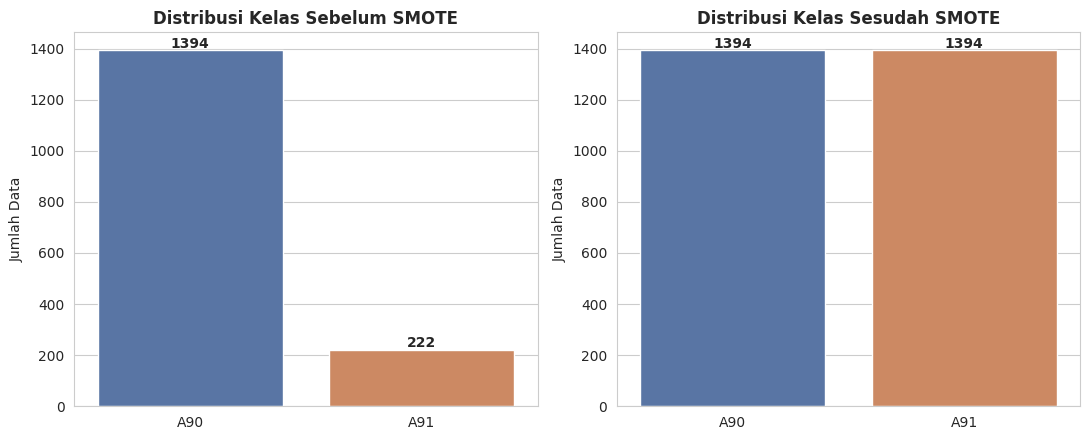

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

sebelum = y_train.value_counts().sort_index()
sesudah = y_train_smote.value_counts().sort_index()
label_kelas = ['A90', 'A91']

sns.barplot(x=label_kelas, y=sebelum.values, hue=label_kelas, palette=['#4C72B0', '#DD8452'], ax=axes[0], legend=False)
axes[0].set_title('Distribusi Kelas Sebelum SMOTE', fontweight='bold')
axes[0].set_ylabel('Jumlah Data')
for i, v in enumerate(sebelum.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

sns.barplot(x=label_kelas, y=sesudah.values, hue=label_kelas, palette=['#4C72B0', '#DD8452'], ax=axes[1], legend=False)
axes[1].set_title('Distribusi Kelas Sesudah SMOTE', fontweight='bold')
axes[1].set_ylabel('Jumlah Data')
for i, v in enumerate(sesudah.values):
    axes[1].text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('smote_distribusi.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Modeling

Tahap *Modeling* membangun model klasifikasi menggunakan algoritma *Decision Tree*. Pencarian kombinasi *hyperparameter* terbaik dilakukan menggunakan *GridSearchCV* dengan validasi silang *Stratified K-Fold* sebanyak 5 *fold*, sebagaimana dijelaskan pada BAB III. Metrik optimasi yang digunakan adalah `recall_macro`, mengingat penelitian ini memprioritaskan kemampuan model dalam mengenali kedua kelas secara seimbang, khususnya kelas A91 yang menjadi perhatian klinis utama.

In [27]:
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

dt_base = DecisionTreeClassifier(random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator=dt_base,
    param_grid=param_grid,
    scoring='recall_macro',
    cv=cv_strategy,
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train_smote, y_train_smote)

print("Pencarian hyperparameter (GridSearchCV) selesai.")

Pencarian hyperparameter (GridSearchCV) selesai.


In [28]:
print("Parameter terbaik:")
for k, v in grid_search.best_params_.items():
    print(f"  {k}: {v}")

print(f"\nBest Score (recall_macro, rata-rata cross-validation): {grid_search.best_score_:.4f}")

model_terbaik = grid_search.best_estimator_
print(f"\nModel terbaik: {model_terbaik}")

Parameter terbaik:
  criterion: gini
  max_depth: 15
  min_samples_leaf: 1
  min_samples_split: 10

Best Score (recall_macro, rata-rata cross-validation): 0.8095

Model terbaik: DecisionTreeClassifier(max_depth=15, min_samples_split=10, random_state=42)


## 5. Evaluation

Tahap *Evaluation* menilai performa model terbaik hasil *GridSearchCV* menggunakan data uji (*testing set*) yang belum pernah dilihat oleh model selama proses pelatihan.

### 5.1 Evaluasi pada Data Testing

In [29]:
y_pred = model_terbaik.predict(X_test)

print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=['A90', 'A91'], digits=4))

Classification Report:

              precision    recall  f1-score   support

         A90     0.8889    0.7816    0.8318       348
         A91     0.2245    0.3929    0.2857        56

    accuracy                         0.7277       404
   macro avg     0.5567    0.5872    0.5588       404
weighted avg     0.7968    0.7277    0.7561       404



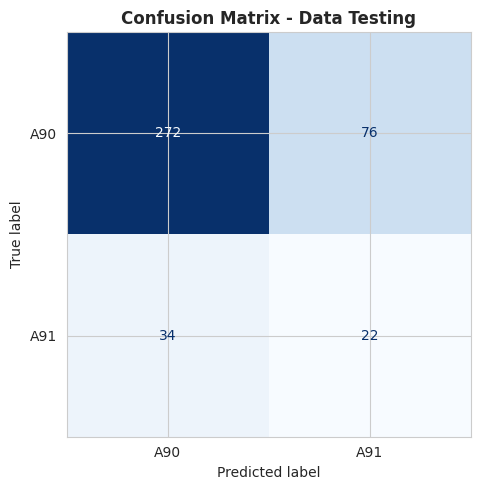


True Negative  (A90 diprediksi A90): 272
False Positive (A90 diprediksi A91): 76
False Negative (A91 diprediksi A90): 34
True Positive  (A91 diprediksi A91): 22


In [30]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5.5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['A90', 'A91'])
disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
ax.set_title('Confusion Matrix - Data Testing', fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negative  (A90 diprediksi A90): {tn}")
print(f"False Positive (A90 diprediksi A91): {fp}")
print(f"False Negative (A91 diprediksi A90): {fn}")
print(f"True Positive  (A91 diprediksi A91): {tp}")

In [31]:
akurasi = accuracy_score(y_test, y_pred)
precision_macro = precision_score(y_test, y_pred, average='macro')
recall_macro = recall_score(y_test, y_pred, average='macro')
f1_macro = f1_score(y_test, y_pred, average='macro')

precision_weighted = precision_score(y_test, y_pred, average='weighted')
recall_weighted = recall_score(y_test, y_pred, average='weighted')
f1_weighted = f1_score(y_test, y_pred, average='weighted')

recall_a91 = recall_score(y_test, y_pred, pos_label=1)
precision_a91 = precision_score(y_test, y_pred, pos_label=1)
f1_a91 = f1_score(y_test, y_pred, pos_label=1)

ringkasan_metrik = pd.DataFrame({
    'Metrik': ['Accuracy', 'Precision (Macro Avg)', 'Recall (Macro Avg)', 'F1-Score (Macro Avg)',
               'Precision (Weighted Avg)', 'Recall (Weighted Avg)', 'F1-Score (Weighted Avg)',
               'Precision (A91)', 'Recall (A91)', 'F1-Score (A91)'],
    'Nilai': [akurasi, precision_macro, recall_macro, f1_macro,
              precision_weighted, recall_weighted, f1_weighted,
              precision_a91, recall_a91, f1_a91]
})
ringkasan_metrik['Nilai'] = ringkasan_metrik['Nilai'].round(4)
ringkasan_metrik

,Metrik,Nilai
0,Accuracy,0.7277
1,Precision (Macro Avg),0.5567
2,Recall (Macro Avg),0.5872
3,F1-Score (Macro Avg),0.5588
4,Precision (Weighted Avg),0.7968
5,Recall (Weighted Avg),0.7277
6,F1-Score (Weighted Avg),0.7561
7,Precision (A91),0.2245
8,Recall (A91),0.3929
9,F1-Score (A91),0.2857


**Interpretasi Metrik Evaluasi:**

*Accuracy* menunjukkan proporsi keseluruhan prediksi yang benar terhadap seluruh data uji, namun pada kondisi kelas tidak seimbang, metrik ini tidak cukup untuk menggambarkan performa model secara menyeluruh karena dapat tetap bernilai tinggi meskipun model gagal mengenali kelas minoritas. Oleh karena itu, *Precision*, *Recall*, dan *F1-Score* pada masing-masing kelas perlu diperhatikan secara terpisah.

Mengingat penelitian ini merupakan sistem pendukung keputusan klinis, **Recall pada kelas A91 menjadi metrik yang paling diprioritaskan**, karena kesalahan *false negative* (pasien A91 yang diprediksi sebagai A90) berisiko menyebabkan pasien dengan kondisi *Dengue Hemorrhagic Fever* yang lebih berat tidak mendapatkan kewaspadaan klinis yang sesuai. Nilai *Recall* A91 pada tabel di atas mencerminkan proporsi pasien A91 aktual yang berhasil dikenali dengan benar oleh model.

### 5.2 Cross Validation

In [32]:
cv_scores = cross_val_score(model_terbaik, X_train_smote, y_train_smote,
                             cv=cv_strategy, scoring='recall_macro')

for i, skor in enumerate(cv_scores, 1):
    print(f"Fold {i}: {skor:.4f}")

print(f"\nMean Recall Macro     : {cv_scores.mean():.4f}")
print(f"Standar Deviasi        : {cv_scores.std():.4f}")

Fold 1: 0.8297
Fold 2: 0.7724
Fold 3: 0.8333
Fold 4: 0.8241
Fold 5: 0.7881

Mean Recall Macro     : 0.8095
Standar Deviasi        : 0.0246


### 5.3 Feature Importance

In [33]:
fitur_importance = pd.DataFrame({
    'Fitur': X.columns,
    'Importance': model_terbaik.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

fitur_importance

,Fitur,Importance
0,Trombosit,0.273298
1,Hematokrit,0.207471
2,Hemoglobin,0.159568
3,Usia,0.148001
4,Leukosit,0.125271
5,Jenis_Kelamin,0.086391


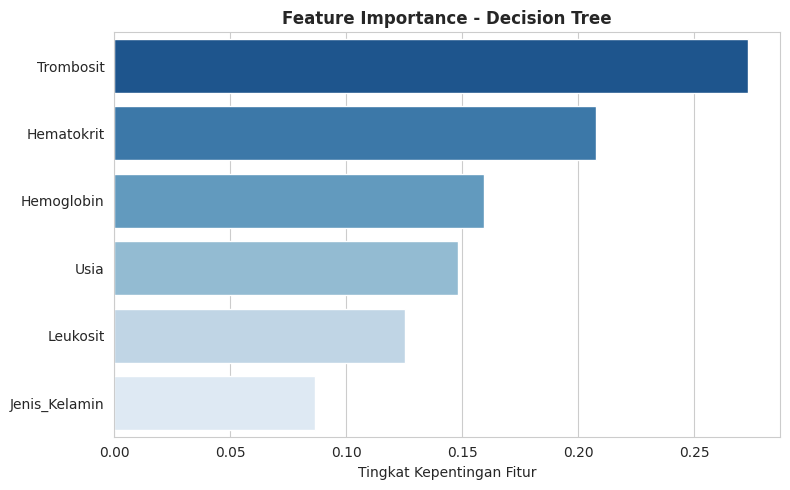

In [34]:
plt.figure(figsize=(8, 5))
sns.barplot(data=fitur_importance, x='Importance', y='Fitur', hue='Fitur',
            palette='Blues_r', legend=False)
plt.title('Feature Importance - Decision Tree', fontweight='bold')
plt.xlabel('Tingkat Kepentingan Fitur')
plt.ylabel('')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretasi Feature Importance:**

Variabel dengan nilai *feature importance* tertinggi merupakan variabel yang paling sering digunakan model sebagai dasar pemisahan (*split*) dalam pembentukan struktur pohon keputusan, sehingga memiliki pengaruh paling besar terhadap hasil klasifikasi kode ICD A90 dan A91. Hasil ini sejalan dengan karakteristik klinis DBD, di mana parameter hematologis seperti trombosit dan hematokrit umumnya menjadi indikator utama dalam penilaian derajat keparahan penyakit oleh tenaga medis.

### 5.4 Visualisasi Decision Tree

In [35]:
kedalaman_model = model_terbaik.get_depth()
jumlah_daun = model_terbaik.get_n_leaves()
print(f"Kedalaman pohon keputusan (full tree) : {kedalaman_model}")
print(f"Jumlah leaf node (full tree)          : {jumlah_daun}")

Kedalaman pohon keputusan (full tree) : 15
Jumlah leaf node (full tree)          : 245


Mengingat struktur pohon keputusan hasil pelatihan dapat memiliki jumlah simpul yang sangat banyak (sebagaimana ditunjukkan oleh kedalaman dan jumlah *leaf node* di atas), visualisasi lengkap pohon dengan kedalaman penuh akan sulit dibaca dalam satu gambar. Oleh karena itu, visualisasi berikut ditampilkan hingga kedalaman 3 tingkat pertama untuk kepentingan interpretasi, sementara seluruh struktur pohon tetap digunakan secara utuh pada proses prediksi model.

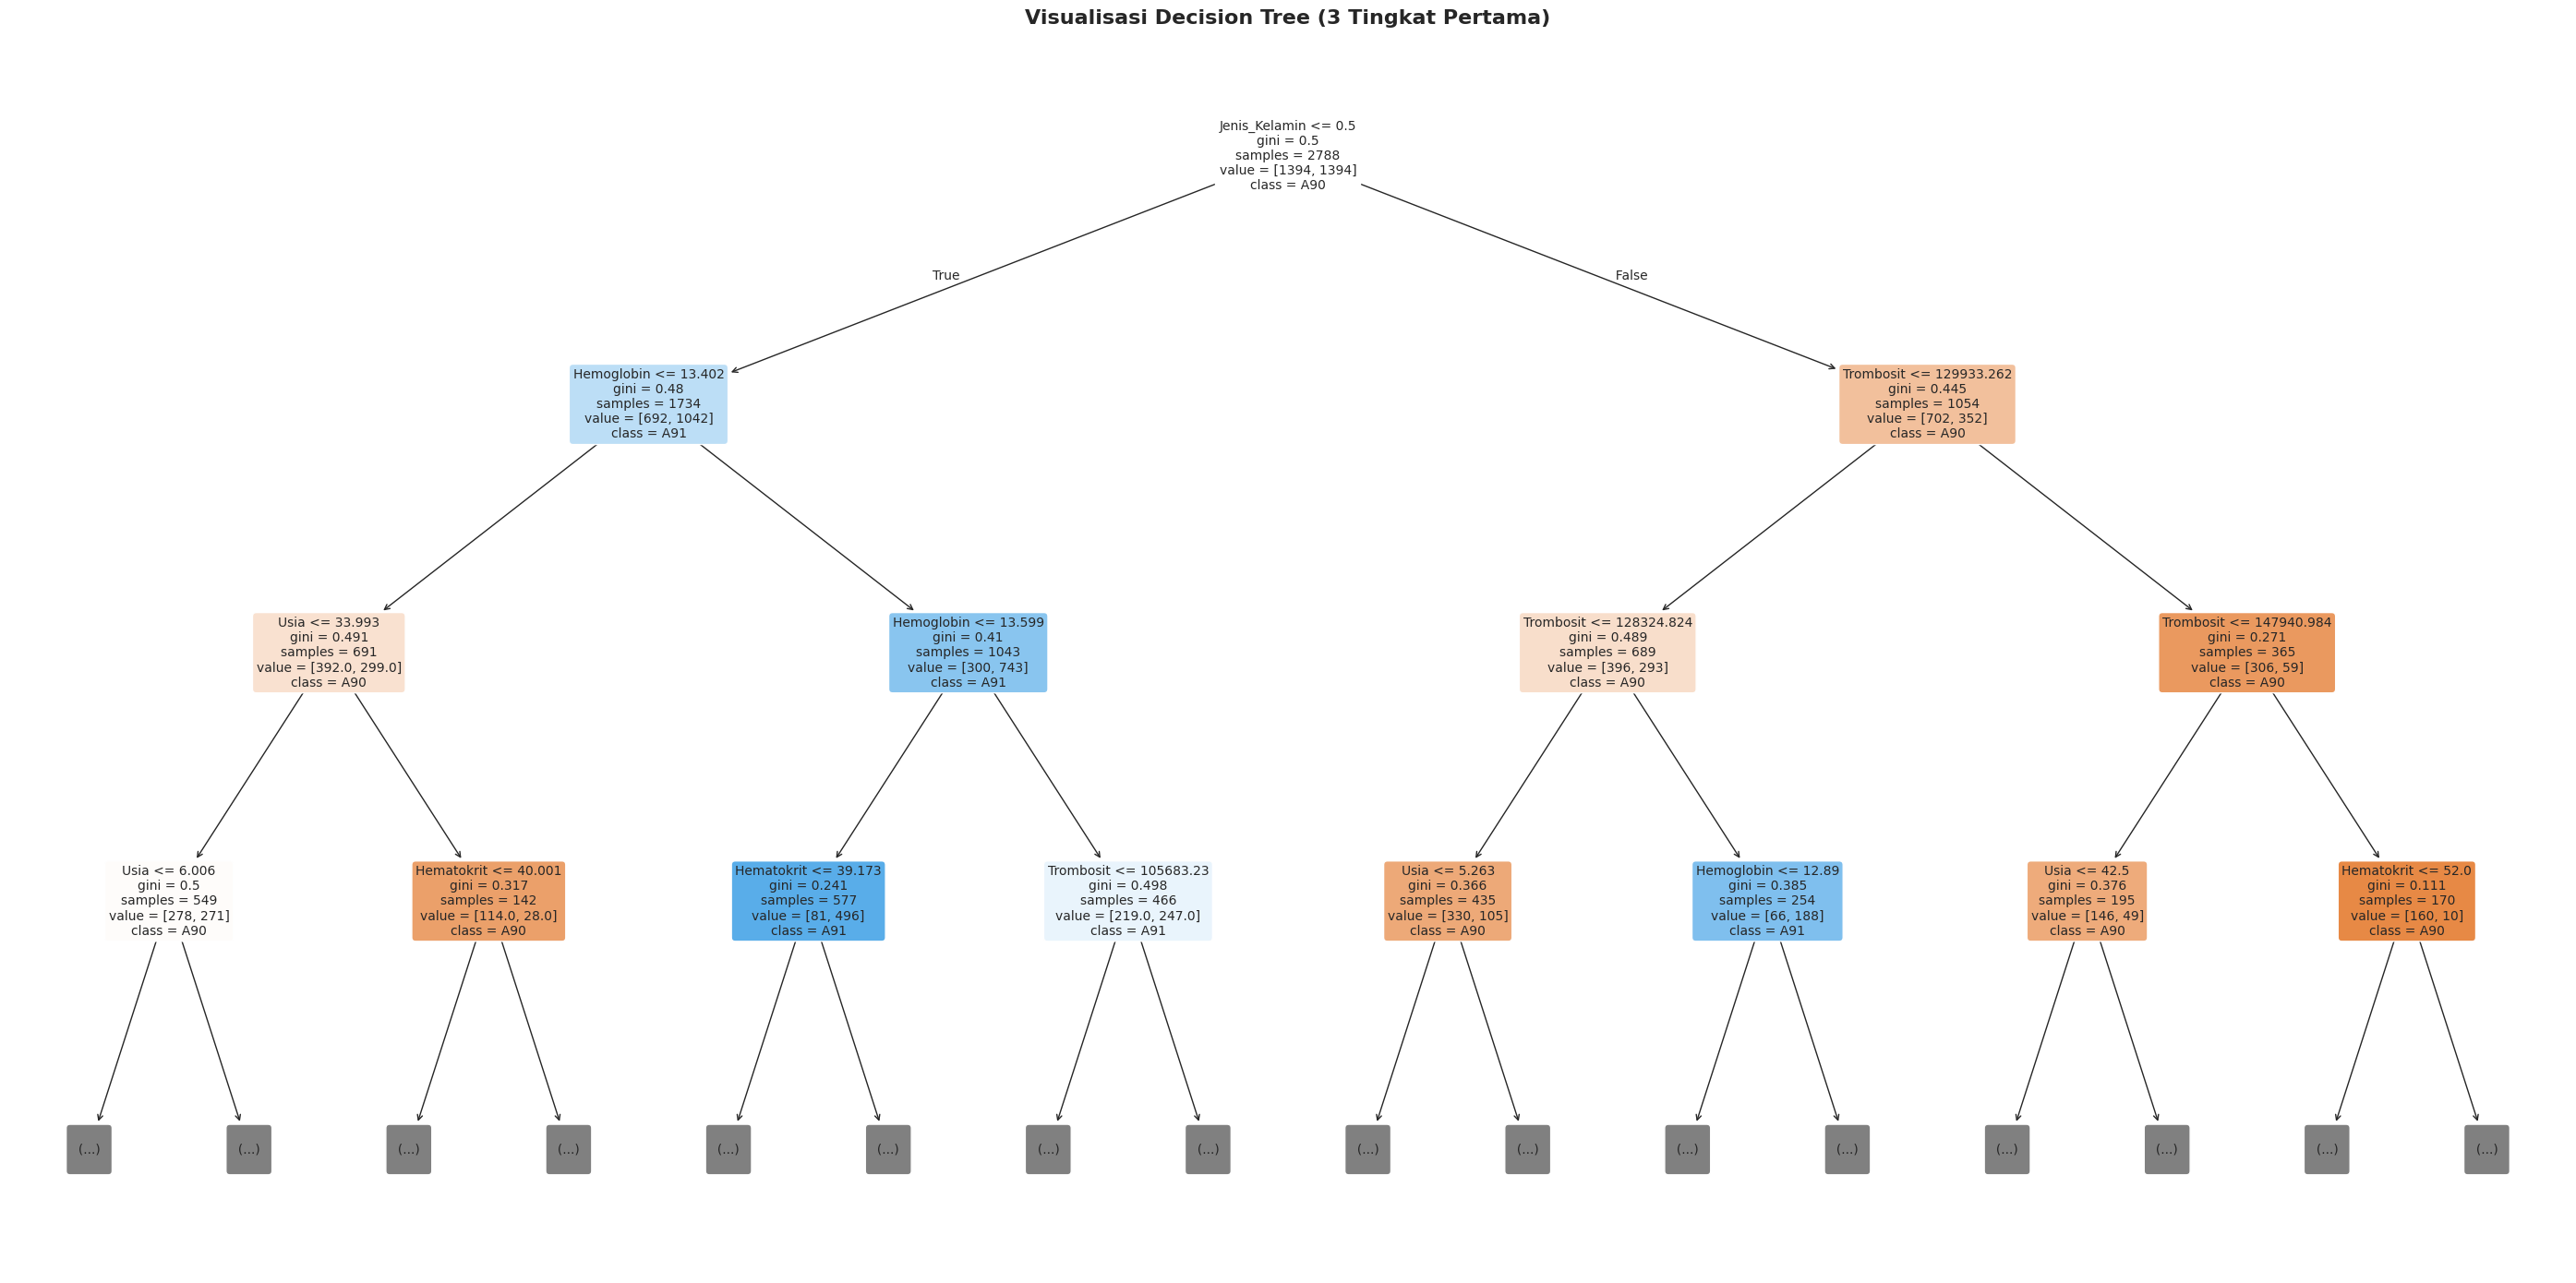

In [36]:
plt.figure(figsize=(28, 14))
plot_tree(model_terbaik, max_depth=3, feature_names=X.columns, class_names=['A90', 'A91'],
          filled=True, rounded=True, fontsize=10, proportion=False)
plt.title('Visualisasi Decision Tree (3 Tingkat Pertama)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.5 Analisis Overfitting

In [37]:
train_pred = model_terbaik.predict(X_train_smote)
train_accuracy = accuracy_score(y_train_smote, train_pred)
test_accuracy = accuracy_score(y_test, y_pred)
gap = train_accuracy - test_accuracy

overfitting_table = pd.DataFrame({
    'Metrik': ['Training Accuracy', 'Testing Accuracy', 'Train-Test Gap'],
    'Nilai': [round(train_accuracy, 4), round(test_accuracy, 4), round(gap, 4)]
})
overfitting_table

,Metrik,Nilai
0,Training Accuracy,0.9247
1,Testing Accuracy,0.7277
2,Train-Test Gap,0.1970


**Interpretasi Analisis Overfitting:**

*Train-Test Gap* yang besar antara akurasi data latih dan data uji mengindikasikan kondisi *overfitting*, yaitu model yang terlalu menyesuaikan diri terhadap pola spesifik pada data latih sehingga kemampuan generalisasinya terhadap data baru menjadi rendah. Sebaliknya, *gap* yang kecil menunjukkan bahwa model mampu melakukan generalisasi dengan baik. Nilai *Train-Test Gap* pada tabel di atas perlu dibandingkan terhadap nilai parameter `max_depth` hasil *GridSearchCV*: apabila *GridSearchCV* memilih nilai `max_depth` yang dibatasi (bukan `None`), hal ini menunjukkan bahwa proses pembatasan kompleksitas pohon melalui validasi silang berhasil menekan risiko *overfitting* dibandingkan model dengan kedalaman tidak terbatas.

## 6. Iterasi Model

Sebagaimana dijelaskan pada BAB III, apabila performa model belum memenuhi kriteria yang diharapkan maka proses iterasi dapat dilakukan kembali pada tahap *Data Preparation* atau *Modeling*. Hasil evaluasi pada Tahap 5 menunjukkan bahwa *Recall* pada kelas A91 (0,3929) masih tergolong rendah untuk kebutuhan sistem pendukung keputusan klinis, meskipun proses penyeimbangan kelas menggunakan SMOTE telah diterapkan. Oleh karena itu, pada tahap ini dilakukan iterasi dengan menguji pendekatan penanganan ketidakseimbangan kelas alternatif, yaitu parameter `class_weight` pada algoritma *Decision Tree*.

Berbeda dengan SMOTE yang menyeimbangkan kelas dengan menambah sampel sintetis pada data latih, parameter `class_weight='balanced'` bekerja dengan memberi bobot kesalahan klasifikasi yang lebih besar pada kelas minoritas (A91) secara langsung pada fungsi pemisahan (*splitting criterion*) pohon keputusan, tanpa mengubah jumlah maupun komposisi data latih. Pendekatan ini diuji sebagai pembanding terhadap model awal (Tahap 4-5) yang menggunakan SMOTE.

### 6.1 Pencarian Ulang Hyperparameter dengan class_weight

In [38]:
param_grid_iterasi = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4, 8],
    'class_weight': ['balanced', None]
}

# Catatan: GridSearchCV pada tahap iterasi ini dilatih langsung pada X_train, y_train
# (TANPA SMOTE), karena penyeimbangan kelas pada iterasi ini ditangani melalui
# parameter class_weight, bukan melalui penambahan sampel sintetis.
grid_search_iterasi = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid_iterasi,
    scoring='recall_macro',
    cv=cv_strategy,
    n_jobs=-1,
    verbose=0
)

grid_search_iterasi.fit(X_train, y_train)

print("Parameter terbaik (hasil iterasi):")
for k, v in grid_search_iterasi.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nBest Score (recall_macro, cross-validation): {grid_search_iterasi.best_score_:.4f}")

model_iterasi = grid_search_iterasi.best_estimator_

Parameter terbaik (hasil iterasi):
  class_weight: balanced
  criterion: entropy
  max_depth: 3
  min_samples_leaf: 1
  min_samples_split: 2

Best Score (recall_macro, cross-validation): 0.6539


### 6.2 Evaluasi Model Hasil Iterasi pada Data Testing

In [39]:
y_pred_iterasi = model_iterasi.predict(X_test)

print("Classification Report - Model Hasil Iterasi:\n")
print(classification_report(y_test, y_pred_iterasi, target_names=['A90', 'A91'], digits=4))

Classification Report - Model Hasil Iterasi:

              precision    recall  f1-score   support

         A90     0.9117    0.9195    0.9156       348
         A91     0.4717    0.4464    0.4587        56

    accuracy                         0.8540       404
   macro avg     0.6917    0.6830    0.6872       404
weighted avg     0.8507    0.8540    0.8523       404



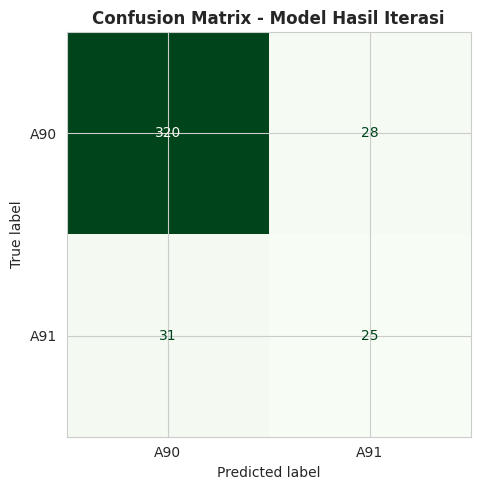

In [40]:
cm_iterasi = confusion_matrix(y_test, y_pred_iterasi)

fig, ax = plt.subplots(figsize=(5.5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_iterasi, display_labels=['A90', 'A91'])
disp.plot(ax=ax, cmap='Greens', colorbar=False, values_format='d')
ax.set_title('Confusion Matrix - Model Hasil Iterasi', fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_iterasi.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.3 Perbandingan Model Awal dan Model Hasil Iterasi

In [41]:
perbandingan_model = pd.DataFrame({
    'Metrik': ['Accuracy', 'Precision (A91)', 'Recall (A91)', 'F1-Score (A91)', 'Recall (Macro Avg)'],
    'Model Awal (SMOTE)': [
        round(accuracy_score(y_test, y_pred), 4),
        round(precision_score(y_test, y_pred, pos_label=1), 4),
        round(recall_score(y_test, y_pred, pos_label=1), 4),
        round(f1_score(y_test, y_pred, pos_label=1), 4),
        round(recall_score(y_test, y_pred, average='macro'), 4),
    ],
    'Model Hasil Iterasi (class_weight)': [
        round(accuracy_score(y_test, y_pred_iterasi), 4),
        round(precision_score(y_test, y_pred_iterasi, pos_label=1), 4),
        round(recall_score(y_test, y_pred_iterasi, pos_label=1), 4),
        round(f1_score(y_test, y_pred_iterasi, pos_label=1), 4),
        round(recall_score(y_test, y_pred_iterasi, average='macro'), 4),
    ]
})
perbandingan_model

,Metrik,Model Awal (SMOTE),Model Hasil Iterasi (class_weight)
0,Accuracy,0.7277,0.8540
1,Precision (A91),0.2245,0.4717
2,Recall (A91),0.3929,0.4464
3,F1-Score (A91),0.2857,0.4587
4,Recall (Macro Avg),0.5872,0.6830


**Interpretasi Perbandingan Model:**

Tabel perbandingan di atas menunjukkan performa Model Awal (menggunakan SMOTE, sesuai metodologi pada BAB III) terhadap Model Hasil Iterasi (menggunakan `class_weight='balanced'`, hasil iterasi pada Tahap 6). Hasil iterasi perlu diperiksa pada tiga aspek sekaligus, bukan hanya *Recall* A91 secara terpisah:

1. **Recall A91** mencerminkan kemampuan model mendeteksi pasien A91 yang sesungguhnya; nilai yang lebih tinggi pada model hasil iterasi menunjukkan lebih sedikit kasus A91 yang luput terdeteksi (*false negative*).
2. **Precision A91** mencerminkan tingkat kepercayaan terhadap prediksi A91 yang dikeluarkan model; nilai yang terlalu rendah berisiko menimbulkan *false alarm* berlebihan yang dapat menurunkan kepercayaan tenaga medis terhadap sistem.
3. **Accuracy** dan ***Recall* Macro Average** memberikan gambaran keseimbangan performa model secara keseluruhan terhadap kedua kelas.

Apabila Model Hasil Iterasi menunjukkan perbaikan pada *Recall* Macro Average serta keseimbangan yang lebih baik antara *Precision* dan *Recall* pada kelas A91 dibandingkan Model Awal, maka Model Hasil Iterasi dipilih sebagai **model final** yang digunakan pada tahap Finalisasi Model. Sebaliknya, apabila perbaikan tidak signifikan atau menyebabkan penurunan performa pada metrik lain secara substansial, Model Awal tetap dipertahankan sebagai model final.

In [42]:
# Pemilihan model final berdasarkan Recall Macro Average tertinggi pada data testing,
# dengan mempertimbangkan keseimbangan Precision-Recall pada kelas A91
recall_macro_awal = recall_score(y_test, y_pred, average='macro')
recall_macro_iterasi = recall_score(y_test, y_pred_iterasi, average='macro')

if recall_macro_iterasi > recall_macro_awal:
    model_final = model_iterasi
    nama_model_final = "Model Hasil Iterasi (class_weight='balanced')"
    y_pred_final = y_pred_iterasi
else:
    model_final = model_terbaik
    nama_model_final = "Model Awal (SMOTE)"
    y_pred_final = y_pred

print(f"Model final yang dipilih: {nama_model_final}")
print(f"Recall Macro Average pada data testing: {recall_score(y_test, y_pred_final, average='macro'):.4f}")

Model final yang dipilih: Model Hasil Iterasi (class_weight='balanced')
Recall Macro Average pada data testing: 0.6830


**Catatan penting untuk BAB IV dan BAB III:** Apabila Model Hasil Iterasi (`class_weight='balanced'`, tanpa SMOTE) terpilih sebagai model final, maka deskripsi metodologi pada BAB III bagian *Data Preparation* dan *Modeling* perlu diperbarui untuk mencerminkan perubahan ini — yaitu penanganan ketidakseimbangan kelas dilakukan melalui parameter `class_weight` pada algoritma *Decision Tree*, bukan (atau sebagai tambahan) melalui SMOTE. SMOTE tetap dapat dipertahankan pada narasi BAB III sebagai metode yang **diuji** pada tahap awal penelitian, dengan iterasi pada Tahap 6 dijelaskan sebagai bagian dari proses CRISP-DM yang bersifat iteratif. Mohon didiskusikan dengan dosen pembimbing mengenai pendekatan penulisan yang paling sesuai.

## 7. Finalisasi Model

Model final hasil Tahap 6 (`model_final`) difinalisasi ke dalam bentuk *pipeline* yang mencakup tahap *preprocessing* (imputasi *missing value*) beserta model *Decision Tree* terbaik. Penyimpanan dalam bentuk *pipeline* bertujuan memastikan proses transformasi data pada saat prediksi data pasien baru dilakukan secara konsisten dengan proses yang digunakan selama pelatihan.

In [43]:
from sklearn.base import clone

preprocessor = ColumnTransformer(
    transformers=[
        ('imputer_numerik', SimpleImputer(strategy='median'), ['Usia', 'Trombosit', 'Hematokrit', 'Hemoglobin', 'Leukosit']),
        ('imputer_kategorikal', SimpleImputer(strategy='most_frequent'), ['Jenis_Kelamin'])
    ],
    remainder='drop'
)

pipeline_dbd = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('classifier', clone(model_final))
])

# Data latih yang digunakan untuk melatih ulang pipeline disesuaikan dengan
# proses pelatihan model_final: data hasil SMOTE apabila model final adalah
# Model Awal, atau data training asli apabila model final adalah Model Hasil Iterasi.
if nama_model_final.startswith("Model Awal"):
    pipeline_dbd.fit(X_train_smote, y_train_smote)
else:
    pipeline_dbd.fit(X_train, y_train)

pipeline_pred = pipeline_dbd.predict(X_test)
print(f"Model final yang digunakan pada pipeline: {nama_model_final}")
print(f"Akurasi pipeline pada data testing: {accuracy_score(y_test, pipeline_pred):.4f}")
print("(Nilai ini digunakan untuk memverifikasi bahwa pipeline final menghasilkan performa yang konsisten dengan model_final pada Tahap Evaluation/Iterasi.)")

Model final yang digunakan pada pipeline: Model Hasil Iterasi (class_weight='balanced')
Akurasi pipeline pada data testing: 0.8540
(Nilai ini digunakan untuk memverifikasi bahwa pipeline final menghasilkan performa yang konsisten dengan model_final pada Tahap Evaluation/Iterasi.)


In [44]:
joblib.dump(pipeline_dbd, 'pipeline_dbd.pkl')
joblib.dump(model_final, 'model_decision_tree.pkl')
joblib.dump(preprocessor, 'preprocessor.pkl')

print("Model dan pipeline berhasil disimpan:")
print("  - pipeline_dbd.pkl        (pipeline lengkap: preprocessing + model)")
print(f"  - model_decision_tree.pkl (model final: {nama_model_final})")
print("  - preprocessor.pkl        (tahap preprocessing/imputasi saja)")

Model dan pipeline berhasil disimpan:
  - pipeline_dbd.pkl        (pipeline lengkap: preprocessing + model)
  - model_decision_tree.pkl (model final: Model Hasil Iterasi (class_weight='balanced'))
  - preprocessor.pkl        (tahap preprocessing/imputasi saja)


## 8. Simpan Dataset

Dataset hasil pembagian data latih dan data uji (sebelum SMOTE) disimpan dalam format CSV agar dapat digunakan kembali pada tahap pengembangan sistem (*Deployment*) tanpa perlu mengulang seluruh proses *Data Preparation*.

In [45]:
X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

print("Dataset berhasil disimpan:")
print("  - X_train.csv")
print("  - X_test.csv")
print("  - y_train.csv")
print("  - y_test.csv")

Dataset berhasil disimpan:
  - X_train.csv
  - X_test.csv
  - y_train.csv
  - y_test.csv


---

## Ringkasan Notebook

Notebook ini telah mendokumentasikan seluruh tahapan penelitian sesuai kerangka kerja CRISP-DM, mulai dari pemahaman data, persiapan data (termasuk konversi format, imputasi *missing value*, pemeriksaan *outlier*, *encoding*, dan penanganan ketidakseimbangan kelas menggunakan SMOTE), pembangunan model *Decision Tree* melalui *GridSearchCV*, evaluasi performa model dengan penekanan pada *Recall* kelas A91, **iterasi model untuk memperbaiki performa pada kelas A91**, hingga finalisasi model terbaik ke dalam bentuk *pipeline* yang siap diimplementasikan pada sistem pendukung keputusan klinis berbasis web sebagaimana dijelaskan pada BAB III.